In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.linalg import hadamard
import random
from sympy import Matrix
import cvxpy as cp
from scipy.linalg import null_space
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import os
import mosek

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],   # default LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 15, 
})

In [2]:
# FUNCTIONS

def all_z3_vectors(n, balanced=True):
    """
    Returns all 3^n vectors in Z_3^n as an array of shape (3^n, n).
    If balanced=True, entries are in {-1,0,1}; otherwise in {0,1,2}.
    """
    N = 3**n
    # base-3 digits in {0,1,2}
    A = np.arange(N, dtype=int)[:, None]
    digits = (A // (3 ** np.arange(n-1, -1, -1))) % 3  # shape (3^n, n)
    if balanced:
        return digits - 1  # map {0,1,2} -> {-1,0,1}
    else:
        return digits
    
def all_zk_vectors(n, k):
    """
    Returns all k^n vectors in Z_k^n as an array of shape (3^k, k).
    If balanced=True, entries are in {-1,0,1}; otherwise in {0,1,2}.
    """
    N = k**n
    # base-k digits in {0,1,2,...}
    A = np.arange(N, dtype=int)[:, None]
    digits = (A // (k ** np.arange(n-1, -1, -1))) % k  # shape (k^n, n)

    return digits

# =========================================================================

def subset_S(n, balanced = True):
    """
    Returns:
      S_mat:  array of shape (|S|, n) with rows in S (balanced digits {-1,0,1})
      index:  dict mapping tuple(a) -> row index in [0, |S|-1]
    """
    A = np.delete(all_z3_vectors(n, balanced=balanced),0,0)       # rows in {-1,0,1}^n
    # Exclude the all-zero row
    # nonzero_mask = np.any(A != 0, axis=1)
    # A_nz = A[nonzero_mask]

    # Find the first nonzero position per row
    # For rows with at least one nonzero, argmax over a reversed cumulative trick:
    # simpler here: loop-free but readable:
    first_nonzero = np.argmax(A != 0, axis=1)  # index of first True along axis=1

    # Pick those whose first nonzero trit is +1
    pick = A[np.arange(A.shape[0]), first_nonzero] == 1
    S_mat = A[pick]

    # Stable lexicographic order inherited from all_z3_vectors
    index = {tuple(row.tolist()): i for i, row in enumerate(S_mat)}
    return S_mat, index

# ===========================================================================

def Fourier_matrix(n,k):
    
    w = np.exp(1j*2*np.pi/k)
    
    Columns = all_zk_vectors(n,k)
    
    F = np.zeros((len(Columns),len(Columns)), dtype=np.complex128)
    
    
    for a in range(len(Columns)):
        for b in range(len(Columns)):
            
            F[a,b] = w**(Columns[a]@Columns[b])
            
    return F
def Fourier_submatrix(n,k):
    
    w = np.exp(1j*2*np.pi/k)
    
    S = subset_S(n,False)[0]
    Columns = all_zk_vectors(n,k)
    
    F = np.zeros((len(S),len(Columns)), dtype=np.complex128)
    
    
    for a in range(len(S)):
        for b in range(len(Columns)):
            
            F[a,b] = w**(S[a]@Columns[b])
            
    return F

def Real_Fourier_submatrix(n,k):
    F = Fourier_submatrix(n,k)
    M = np.vstack([F.real, F.imag])
    return M

# ============================================================================


def Eff_subset_S(n, r, balanced = True):
    S = subset_S(n,balanced=balanced)[0]
    Eff_S = np.array(S[np.random.choice(len(S),size=r,replace = False)])
    
    return Eff_S

def Eff_Fourier_submatrix(Eff_S, C, r, ratio,k=3):
    
    w = np.exp(1j*2*np.pi/k)
    
    
    Eff_Columns = np.array(C[np.random.choice(len(C),size=int(r*ratio),replace = False)])
    
    F = np.zeros((len(Eff_S),len(Eff_Columns)), dtype=np.complex128)
    
    
    for a in range(len(Eff_S)):
        for b in range(len(Eff_Columns)):
            
            F[a,b] = w**(Eff_S[a]@Eff_Columns[b])
            
    return F

def Eff_Real_Fourier_submatrix(Eff_S, C, r, ratio,k=3):
    
    w = np.exp(1j*2*np.pi/k)
    
    Eff_Columns = np.array(C[np.random.choice(len(C),size=int(r*ratio),replace = False)])
    
    F = np.zeros((len(Eff_S),len(Eff_Columns)), dtype=np.complex128)
    
    
    for a in range(len(Eff_S)):
        for b in range(len(Eff_Columns)):
            
            F[a,b] = w**(Eff_S[a]@Eff_Columns[b])        
    M = np.vstack([F.real, F.imag])
    return M

# ========================================================================

# Check if W is feasible
def check_feasible(W):

    x = cp.Variable(W.shape[1])
    objective = cp.Minimize(cp.sum(x))
    constraints = [W @ x == 0, x >= 1]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver = cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    LP_has_solution = 0
    W_has_full_rank = 0
    
    if type(x.value) == np.ndarray:
        LP_has_solution = 1
    if W.shape[0]- np.linalg.matrix_rank(W)==0:
        W_has_full_rank = 1
    feasible = LP_has_solution * W_has_full_rank
    
    return bool(feasible)

# ========================================================================

# (Optional) avoid BLAS oversubscription if Eff_Real_Fourier_submatrix uses NumPy linear algebra
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

def check_once(Eff_S, C, r, ratio, seed=None,k=3):
    if seed is not None:
        np.random.seed(seed)  # reproducible, and isolates RNG streams across workers
    M = Eff_Real_Fourier_submatrix(Eff_S, C, r, ratio,k=k)
    return 1 if check_feasible(M) else 0

In [3]:
# Varying the number of modes
k = 3
r = 40
ratios_modes = []
for n in tqdm(range(6, 16)):
    ratios_modes.append([])
    Eff_S =Eff_subset_S(n,r,False)
    C = all_zk_vectors(n, k)

    ratio_grid = np.arange(2, 6, 0.1)
    # parallelize the 20 Monte-Carlo trials per ratio
    for ratio in ratio_grid:
        seeds = np.random.SeedSequence().generate_state(20)
        feasible_counts = Parallel(n_jobs=12, prefer="processes")(
            delayed(check_once)(Eff_S, C, r, ratio, int(s)) for s in seeds
        )
        ratios_modes[-1].append(sum(feasible_counts) / 20.0)

ratios_modes = np.array(ratios_modes)

  0%|          | 0/10 [00:00<?, ?it/s]

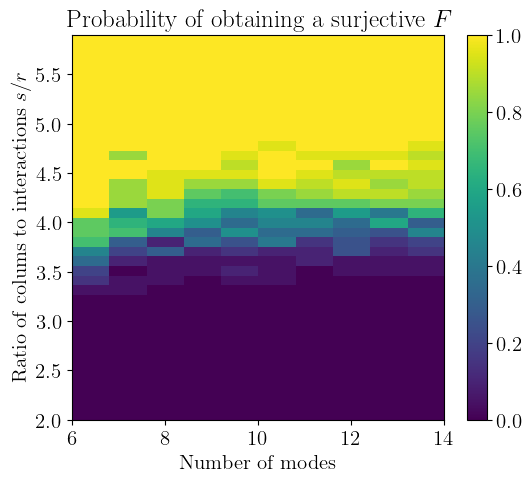

In [9]:

n_vals = np.arange(6, 15)                     # x-axis: number of modes
k_vals = np.arange(2, 6, 0.1)                 # y-axis: ratio values from 3.0 to 4.9

plt.figure(figsize=(6, 5))
im = plt.imshow(
    ratios_modes.T,                                 # transpose to get k on y-axis
    origin='lower',                           # so lower k is at bottom
    aspect='auto',
    extent=[n_vals[0], n_vals[-1], k_vals[0], k_vals[-1]],
    cmap='viridis'
)

plt.colorbar(im)
plt.xlabel('Number of modes')
plt.ylabel(r'Ratio of colums to interactions $s/r$')
plt.title('Probability of obtaining a surjective $F$')
plt.grid(False)
plt.savefig("eff_relax_modes.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')
plt.show()

In [5]:
# Varying the root of unity
n = 8
r = 40
ratios_root = []

Eff_S = Eff_subset_S(n,r,False)

for k in tqdm(range(2, 8)):
    
    ratios_root.append([])
    C = all_zk_vectors(n, k)

    ratio_grid = np.arange(2, 6, 0.1)
    # parallelize the 20 Monte-Carlo trials per ratio
    for ratio in ratio_grid:
        seeds = np.random.SeedSequence().generate_state(20)
        feasible_counts = Parallel(n_jobs=12, prefer="processes")(
            delayed(check_once)(Eff_S, C, r, ratio, int(s),k) for s in seeds
        )
        ratios_root[-1].append(sum(feasible_counts) / 20.0)

ratios_root = np.array(ratios_root)

  0%|          | 0/6 [00:00<?, ?it/s]

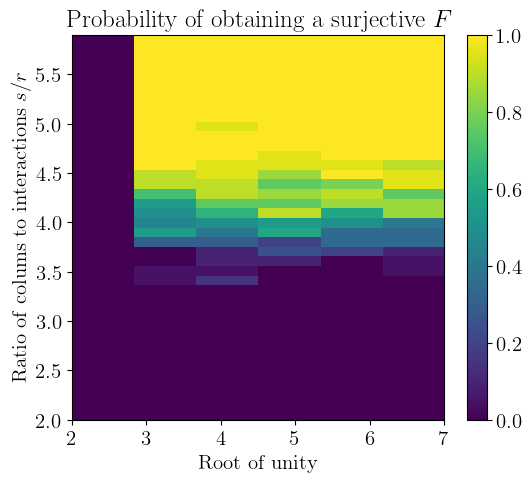

In [10]:

n_vals = np.arange(2, 8, dtype=int)                     # x-axis: root of unity
k_vals = np.arange(2, 6, 0.1)                 # y-axis: ratio values from 3.0 to 4.9

plt.figure(figsize=(6, 5))
im = plt.imshow(
    ratios_root.T,                                 # transpose to get k on y-axis
    origin='lower',                           # so lower k is at bottom
    aspect='auto',
    extent=[n_vals[0], n_vals[-1], k_vals[0], k_vals[-1]],
    cmap='viridis'
)

plt.colorbar(im)
plt.xlabel('Root of unity')
plt.ylabel(r'Ratio of colums to interactions $s/r$')
plt.title('Probability of obtaining a surjective $F$')
plt.grid(False)
plt.savefig("eff_relax_root.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')
plt.show()

In [ ]:
# Varying the number of interactions
n = 8
k = 3
ratios_terms = []

S = subset_S(n, False)[0]
C = all_zk_vectors(n, k)

for r in tqdm(np.arange(10, 100, 10)):
    
    Eff_S = np.array(S[np.random.choice(len(S), size=r, replace=False)])
    ratios_terms.append([])
   

    ratio_grid = np.arange(2, 6, 0.1)
    # parallelize the 20 Monte-Carlo trials per ratio
    for ratio in ratio_grid:
        seeds = np.random.SeedSequence().generate_state(20)
        feasible_counts = Parallel(n_jobs=12, prefer="processes")(
            delayed(check_once)(Eff_S, C, r, ratio, int(s)) for s in seeds
        )
        ratios_terms[-1].append(sum(feasible_counts) / 20.0)

ratios_terms = np.array(ratios_terms)



  0%|          | 0/9 [00:00<?, ?it/s]

10
20
30
40
50
60
70
80
90


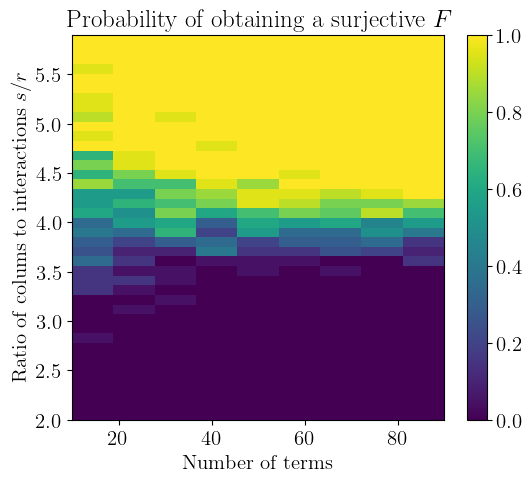

In [11]:

n_vals = np.arange(10, 100, 10)                     # x-axis: Number of terms
k_vals = np.arange(2, 6, 0.1)                 # y-axis: ratio values from 3.0 to 4.9

plt.figure(figsize=(6, 5))
im = plt.imshow(
    ratios_terms.T,                                 # transpose to get k on y-axis
    origin='lower',                           # so lower k is at bottom
    aspect='auto',
    extent=[n_vals[0], n_vals[-1], k_vals[0], k_vals[-1]],
    cmap='viridis'
)

plt.colorbar(im)
plt.xlabel('Number of terms')
plt.ylabel(r'Ratio of colums to interactions $s/r$')
plt.title('Probability of obtaining a surjective $F$')
plt.grid(False)
plt.savefig("eff_relax_num_terms.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')
plt.show()